#### Original version written by Jack Hayes, University of Washington <jhayes@uw.edu>
#### Shashank modified slightly for the following:
* colorbar limits was automated for site-specific processing (cmin, cmax)
* For spaceborne lidar figures, basemap was changes to ESRI worldimagery to provide further context
* DEM colormap changed to plasma, to account for black background conflict with the black color of the colormap

In [1]:

import geopandas as gpd

import coincident
import geopandas as gpd 
import matplotlib.pyplot as plt
from rasterio.plot import show
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
from matplotlib_scalebar.scalebar import ScaleBar
from scipy import stats
import sliderule
from sliderule import earthdata, icesat2, gedi
from shapely.geometry import box
import numpy as np
from coincident.io.xarray import to_dataset
import matplotlib
import contextily
%matplotlib inline

/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/io/download.py:26: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/panfs/ccds02/nobackup/people/sbhusha1/sw/coincident/src/coincident/search/main.py:14: UserWarning: Unable to authenticate with Maxar API. Please set MAXAR_API_KEY environment variable.
  from coincident.search import neon_api, opentopo_api, stac, wesm
Could not save font_manager cache [Errno 28] No space left on device: '/tmp/mpl_sbhusha1/fontlist-v390.json.matplotlib-lock'


In [2]:
gf_is2_stac = gpd.read_file('20250718_PCD_neon_is2_tracks.geojson')
gf_gedi_stac = gpd.read_file('20250718_PCD_neon_gedi_tracks.geojson')

In [3]:
gf_gedi_stac.tail(1)

,neon_id,gedi_granule_id,date,geometry
4,WREF,GEDI02_A_2019206022612_O03482_02_T00370_02_003...,2019-07-25,"POLYGON ((-122.46111 45.5651, -122.46111 45.62..."


In [4]:
gf_is2_stac.tail(3)

,neon_id,is2_granule_id,date,geometry
3,WREF,ATL03_20190529005739_09280306_006_02,2019-05-29,"POLYGON ((-122.00876 46.26191, -122.00256 46.3..."
4,WREF,ATL03_20190522125829_08290302_006_02,2019-05-22,"POLYGON ((-122.05547 45.8676, -122.11879 46.30..."
5,WREF,ATL03_20190821083817_08290402_006_02,2019-08-21,"POLYGON ((-122.11655 46.30569, -121.95311 46.3..."


In [5]:
is2_ids = [str(value)+'.h5' for value in gf_is2_stac.tail(3).is2_granule_id.values.tolist()]

In [6]:
is2_ids

['ATL03_20190529005739_09280306_006_02.h5',
 'ATL03_20190522125829_08290302_006_02.h5',
 'ATL03_20190821083817_08290402_006_02.h5']

In [7]:
gedi_ids = [str(value)+'.h5' for value in gf_gedi_stac.tail(1).gedi_granule_id.values.tolist()]

In [8]:

datetime = ["2019-05-29T00:00:00Z", "2019-08-21T00:00:00Z"] # T00:00:00Z for SLideRule call



In [9]:
sliderule.init("slideruleearth.io", verbose=False)
earthdata.set_max_resources(max_resources=1000)


In [10]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/neon_pcd_products/WREF_processing

/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/neon_pcd_products/WREF_processing


In [11]:
ls

nuth_canopy_align/
stereo_WV02WV02_20190724_10300100965CBA00_10300100962F3500/
WREF-DSM_mos_fig.png
WREF-DSM_mos.tif
WREF-DSM_mos.tif.aux.xml
WREF-DTM_fill_window_size_4_mos.tif
WREF-DTM_fill_window_size_4_mos.tif.aux.xml
WREF-DTM_no_fill_mos.tif
WREF-DTM_no_fill_mos.tif.aux.xml
WREF-fourway_overlap_mask.tif
WREF-fourway_overlap_mask.tif.aux.xml
WREF-intensity_mos.tif
WREF-intensity_mos.tif.aux.xml
WREF_stereo_WV02WV02_20190724_10300100965CBA00_10300100962F3500_raster_gallery_figure.png


In [12]:
da_lidar_dsm = rxr.open_rasterio('../../../neon/WREF_processing_save_pointcloud/DSM_98perc_warp.tif', masked=True).squeeze()
da_lidar_dsm

<xarray.DataArray (y: 7387, x: 3436)> Size: 102MB
[25381732 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 27kB 5.75e+05 5.75e+05 ... 5.784e+05 5.784e+05
  * y            (y) float64 59kB 5.077e+06 5.077e+06 ... 5.07e+06 5.07e+06
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:  1.0
    add_offset:    0.0

In [13]:
da_lidar_dsm.rio.crs

CRS.from_wkt('PROJCRS["WGS 84 (G2139) / UTM 10N",BASEGEOGCRS["WGS 84 (G2139)",DYNAMIC[FRAMEEPOCH[2016]],DATUM["World Geodetic System 1984 (G2139)",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",9754]],CONVERSION["UTM zone 10N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-123,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["False easting",500000,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False northing",0,LENGTHUNIT["metre",1],ID["EPSG",8807]]],CS[Cartesian,3],AXIS["(E)",north,MERIDIAN[90,ANGLEUNIT["degree",0.0174532925199433]],ORDER[1],LENGTHUNIT["metre",1]],AXIS["(N)",north,MERIDIAN[0,ANGLEUNIT["degree",0.0174532925199433]],ORDER[2],LENGTHUNIT["metre

In [14]:
da_bounds = da_lidar_dsm.rio.bounds()  # (minx, miny, maxx, maxy)
da_box = box(*da_bounds)
gf_search = gpd.GeoDataFrame(geometry=[da_box],
                             columns=['geometry'],
                             crs = da_lidar_dsm.rio.crs)
gf_search = gf_search.to_crs(4326)

poly_sliderule = sliderule.toregion(gf_search)['poly']
#https://nbviewer.org/github/ICESat2-SlideRule/sliderule-python/blob/main/examples/phoreal.ipynb
parms = {
    "poly": poly_sliderule,
    "t0": datetime[0],
    "t1": datetime[1],
}

parms_gedi = {
    "poly": poly_sliderule,
    "t0": datetime[0],
    "t1": datetime[1],
    'anc_fields':['master_frac','energy_total','rh']
}

In [15]:
gf_is2 = icesat2.atl06p(parms,
                        resources=is2_ids)



In [16]:
gf_gedi = gedi.gedi02ap(parms_gedi,
                        resources=gedi_ids)

In [17]:
def return_98_perc(row):
    perc_98 = row['rh'][-3]
    return perc_98+row['elevation_lm']

In [18]:
gf_gedi.iloc[[0]].rh.values[0]

array([-3.25, -2.32, -1.04, -0.18,  0.59,  1.42,  2.24,  3.4 ,  4.64,
        5.61,  6.55,  7.6 ,  8.65,  9.4 , 10.04, 10.6 , 11.12, 11.57,
       11.98, 12.32, 12.66, 12.96, 13.26, 13.56, 13.86, 14.12, 14.38,
       14.64, 14.87, 15.09, 15.32, 15.54, 15.73, 15.92, 16.1 , 16.29,
       16.48, 16.67, 16.85, 17.04, 17.23, 17.42, 17.57, 17.75, 17.94,
       18.09, 18.24, 18.39, 18.54, 18.69, 18.84, 18.95, 19.1 , 19.21,
       19.36, 19.48, 19.63, 19.74, 19.89, 20.  , 20.15, 20.3 , 20.45,
       20.6 , 20.75, 20.9 , 21.09, 21.24, 21.39, 21.57, 21.72, 21.87,
       22.06, 22.21, 22.36, 22.55, 22.7 , 22.88, 23.07, 23.26, 23.45,
       23.67, 23.86, 24.05, 24.23, 24.42, 24.65, 24.83, 25.06, 25.28,
       25.51, 25.77, 26.03, 26.33, 26.67, 27.08, 27.49, 27.98, 28.43,
       29.03, 30.04], dtype=float32)

In [19]:
gf_gedi['perc_98'] = gf_gedi.apply(return_98_perc,axis=1)

In [20]:
gf_gedi

,elevation_lm,solar_elevation,flags,elevation_hr,sensitivity,orbit,track,beam,geometry,rh,master_frac,energy_total,perc_98
time,,,,,,,,,,,,,
2019-07-25 03:06:03.938780672,1004.560974,5.649856,130,1034.606079,0.975954,3482,370,3,POINT (-122.03517 45.80072),"[-3.25, -2.32, -1.04, -0.18, 0.59, 1.42, 2.24,...",0.938781,6775.931152,1032.990967
2019-07-25 03:06:03.947044608,1023.270325,5.649514,130,1052.641113,0.977961,3482,370,3,POINT (-122.03453 45.80096),"[-2.28, -1.27, -0.44, 0.29, 1.04, 1.61, 2.13, ...",0.947045,7392.964355,1050.840332
2019-07-25 03:06:03.955308800,1030.596313,5.649172,130,1056.333130,0.980251,3482,370,3,POINT (-122.03388 45.80121),"[-4.94, -3.78, -3.14, -2.65, -2.28, -1.98, -1....",0.955309,7425.173828,1054.496338
2019-07-25 03:06:03.963572736,1021.545654,5.648830,130,1052.527344,0.984264,3482,370,3,POINT (-122.03324 45.80145),"[-4.12, -3.14, -2.58, -2.09, -1.68, -1.27, -0....",0.963573,7247.999512,1050.425659
2019-07-25 03:06:03.971836928,999.833740,5.648487,130,1020.438232,0.959564,3482,370,3,POINT (-122.03259 45.8017),"[-8.84, -8.16, -7.6, -7.11, -6.63, -6.18, -5.7...",0.971837,8864.498047,1017.843750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-25 03:06:04.992495616,856.615662,5.617085,130,892.319458,0.989672,3482,370,8,POINT (-121.9915 45.79596),"[-9.85, -8.01, -5.73, -3.55, -2.47, -1.61, -0....",0.992496,15775.917969,889.245667
2019-07-25 03:06:04.992496128,767.499390,5.633083,130,783.646118,0.978742,3482,370,0,POINT (-121.99304 45.83506),"[-5.09, -4.3, -3.7, -3.14, -2.62, -2.13, -1.68...",0.992496,7664.435547,782.069397
2019-07-25 03:06:05.000760320,761.619873,5.632740,130,822.048462,0.979182,3482,370,0,POINT (-121.9924 45.83531),"[-3.59, -2.65, -1.53, -0.44, 0.26, 1.04, 1.68,...",0.000760,7826.349609,819.979858


In [21]:
da_stereo_dem = rxr.open_rasterio(
    'nuth_canopy_align/nuth-trans_source-DEM.tif', 
    masked=True).squeeze()

In [22]:
  
da_lidar_hs = coincident.plot.gdaldem(
    da_lidar_dsm, "hillshade"
)
da_stereo_hs = coincident.plot.gdaldem(
    da_stereo_dem, "hillshade"
)

In [23]:

data_is2_p = gf_is2.to_crs(da_lidar_dsm.rio.crs)
da_points = data_is2_p.get_coordinates().to_xarray()
samples = da_lidar_dsm.interp(da_points).drop_vars(['band','spatial_ref']).to_dataframe(name='3dep')
data_is2_p['elev_diff'] = data_is2_p.h_mean - samples['3dep']

data_gedi_p = gf_gedi.to_crs(da_lidar_dsm.rio.crs)
gedi_points = data_gedi_p.get_coordinates().to_xarray()
samples = da_lidar_dsm.interp(gedi_points).drop_vars(['band','spatial_ref']).to_dataframe(name='3dep')
data_gedi_p['elev_diff'] = data_gedi_p['perc_98'] - samples['3dep']

In [24]:
np.nanpercentile(da_lidar_dsm.to_numpy(),2)

np.float32(541.5127)

In [25]:
np.nanpercentile(da_lidar_dsm.to_numpy(),98)

np.float32(976.25757)

In [47]:
da_lidar_dsm.min().item()

366.8896484375

In [26]:

gf_wc = coincident.search.search(
    dataset="worldcover",
    intersects=gf_search,
    datetime=["2021"],
)
try:
    ds_wc = to_dataset(
        gf_wc,
        bands=["map"],
        aoi=gf_search,
        mask=True,
        # resolution=0.00081,  # ~90m
    )
except Exception:
    # mask=True will fail on very small aois (e.g.20mx20m)
    ds_wc = to_dataset(
        gf_wc,
        bands=["map"],
        aoi=gf_search,
        # resolution=0.00081,  # ~90m
    )
ds_wc = ds_wc.rio.reproject(da_lidar_dsm.rio.crs)
ds_wc = ds_wc.rio.reproject_match(da_lidar_dsm)

In [27]:
#https://xyzservices.readthedocs.io/en/stable/introduction.html
import xyzservices
terrain_map = xyzservices.providers.Esri.WorldImagery()

In [29]:
terrain_map

{'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
 'variant': 'World_Imagery',
 'html_attribution': 'Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community',
 'attribution': 'Tiles (C) Esri -- Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community',
 'name': 'Esri.WorldImagery'}

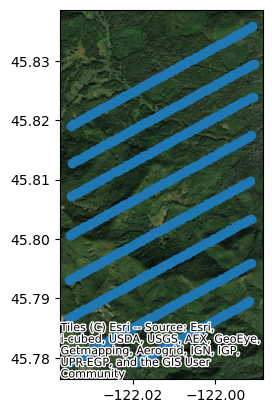

In [39]:
f,ax = plt.subplots()
gf_gedi.plot(ax=ax)
contextily.add_basemap(ax, source=contextily.providers.Esri.WorldImagery,crs=gf_gedi.crs)

In [55]:
fig.savefig('/panfs/ccds02/home/sbhusha1/notebooks/pcd/WY_FEMA_summary_plot_plasma_final.png',dpi=300,bbox_inches='tight',pad_inches=0.1)

CPU times: user 36.7 s, sys: 15.6 s, total: 52.3 s
Wall time: 55.7 s


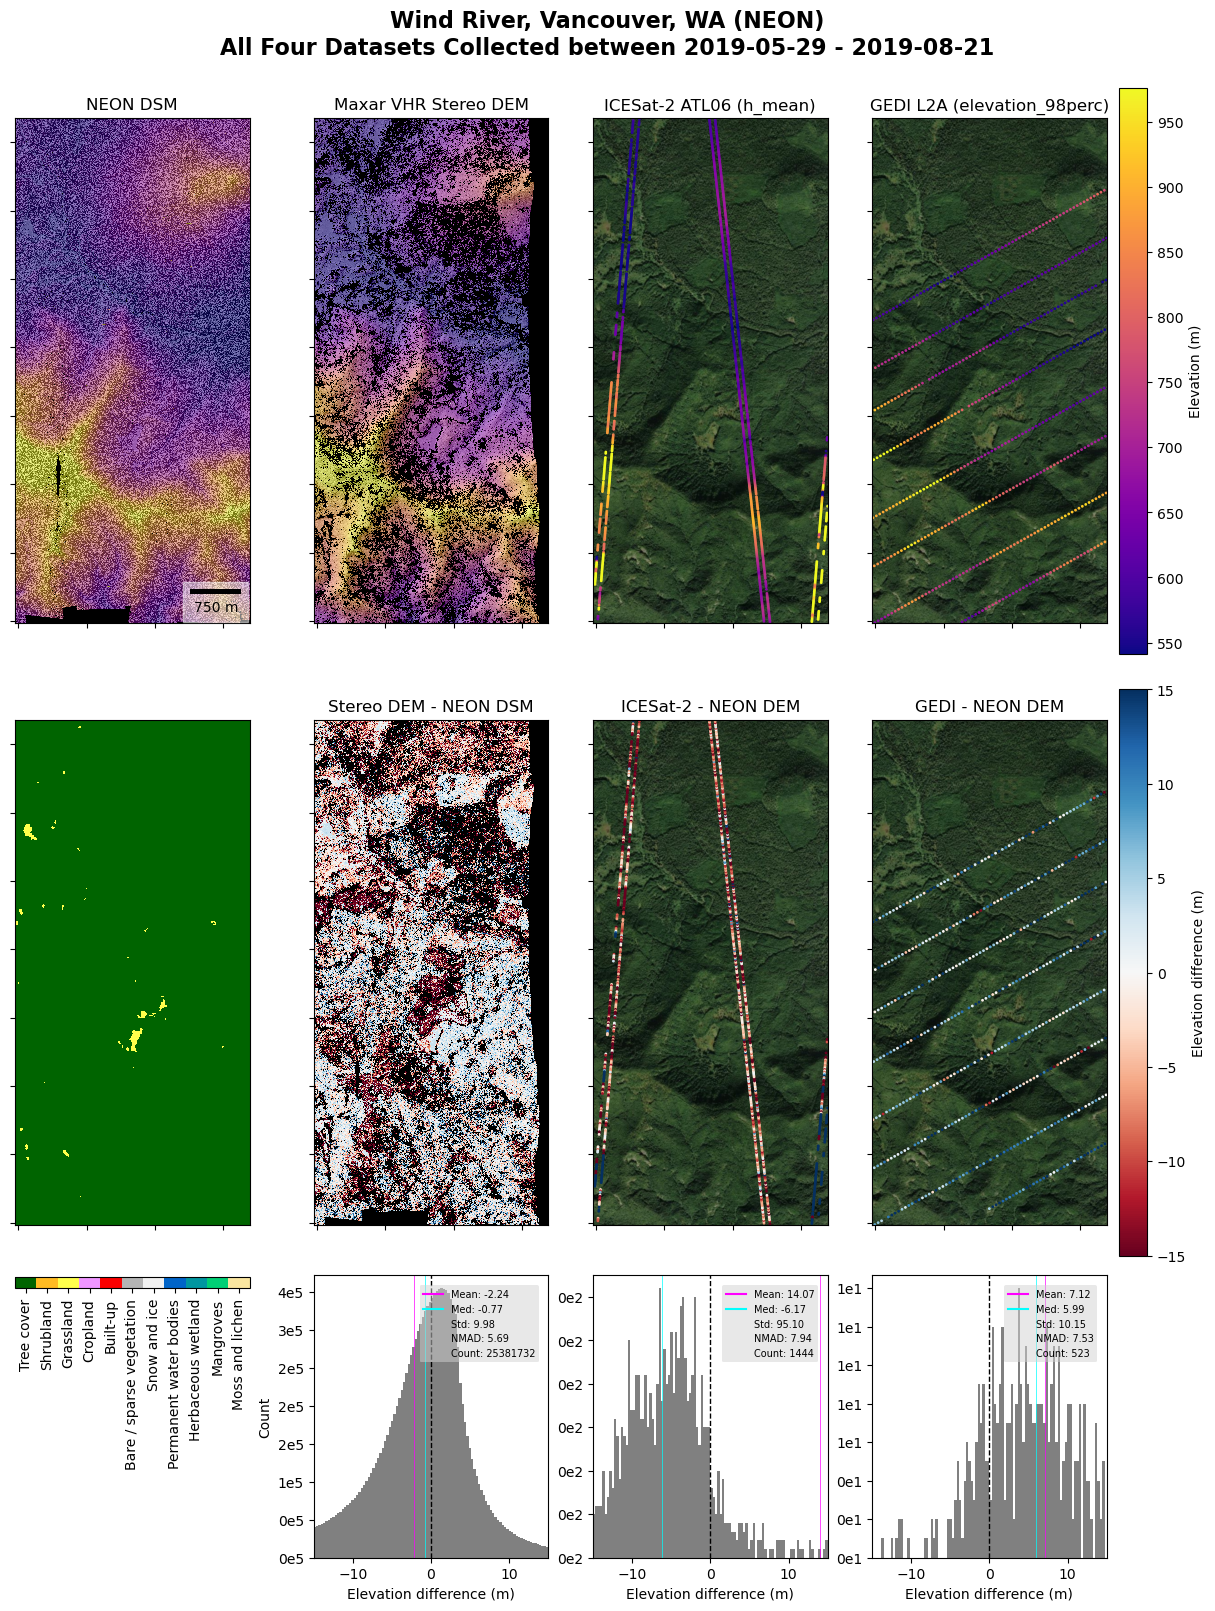

In [29]:
%%time
figsize=(12, 16)

elevation_cmap = 'plasma'
# cmin = 1100
# cmax = 1300
cmin = np.nanpercentile(da_lidar_dsm.to_numpy(),2)
cmax = np.nanpercentile(da_lidar_dsm.to_numpy(),98)

diff_cmap = 'RdBu'
dmin = -15
dmax = 15

def clear_labels(ax):
    ax.xaxis.set_major_formatter(plt.NullFormatter())
    ax.yaxis.set_major_formatter(plt.NullFormatter())

gs_kw = dict(width_ratios=[1,]*4, height_ratios=[2, 2, 1])
fig, axd = plt.subplot_mosaic([['3dep', 'stereo', 'is2', 'gedi'],
                               ['worldcover', 'diff_stereo', 'diff_is2', 'diff_gedi'],
                               ['wc_legend', 'hist_stereo', 'hist_is2', 'hist_gedi'],
                               ],
                              gridspec_kw=gs_kw,
                              figsize=figsize,
                              layout="constrained")

# Share x and y axes for first two rows only
for key in ['stereo', 'is2', 'gedi']:
    axd[key].sharex(axd['3dep'])
    axd[key].sharey(axd['3dep'])
    axd[f'diff_{key}'].sharex(axd['worldcover'])
    axd[f'diff_{key}'].sharey(axd['worldcover'])
    # Let histogram y-axes be independent

# TOP ROW
# ----------------
def plot_dem(da, da_hs, ax, title='', cmap=elevation_cmap, vmin=cmin, vmax=cmax, hs=False):
    
    if hs:
        #da_hs.plot.imshow(ax=ax, cmap="gray", add_colorbar=False, add_labels=False, alpha=1);
        da.plot.imshow(ax=ax, cmap='RdBu', add_colorbar=False, add_labels=False, 
                                       vmin=vmin, vmax=vmax, alpha=1);
        ax.set_facecolor('black')
    else:
        da_hs.plot.imshow(ax=ax, cmap="gray", add_colorbar=False, add_labels=False, alpha=1);
        da.plot.imshow(ax=ax, cmap=cmap, add_colorbar=False, add_labels=False, 
                                       vmin=vmin, vmax=vmax, alpha=0.5);
        ax.set_facecolor('gray')
    ax.set_title(title)
    
    clear_labels(ax)

def plot_altimeter(gf, ax, column='h_li', title='', cmap=elevation_cmap, vmin=cmin, vmax=cmax, add_colorbar=False, **kwargs):
    ax.set_facecolor('black')
    #da_lidar_hs.plot.imshow(ax=ax, cmap="gray", add_colorbar=False, add_labels=False, alpha=1);
    gf.plot(ax=ax, column=column, s=1, aspect=None, cmap=cmap, legend=add_colorbar, vmin=vmin, vmax=vmax, 
            alpha=1, **kwargs)
    contextily.add_basemap(ax=ax,attribution=False,crs=gf.crs,source=terrain_map)
    ax.set_title(title)
    clear_labels(ax)

key = '3dep'
plot_dem(da_lidar_dsm, da_lidar_hs, axd[key], 'NEON DSM')
axd[key].set_facecolor('gray')
scalebar = ScaleBar(
    1, 
    "m",  
    length_fraction=.25,
    location="lower right",
    box_alpha=0.5,
    box_color="white",
    color="black",        
    pad=0.5,
    frameon=True
)
axd[key].add_artist(scalebar)
axd[key].set_aspect('equal')

key = 'stereo'
plot_dem(da_stereo_dem, da_stereo_hs, axd[key], 'Maxar VHR Stereo DEM')
axd[key].set_aspect('equal')
axd[key].set_facecolor('gray')

key = 'is2'
plot_altimeter(data_is2_p, axd[key], 'h_mean', 'ICESat-2 ATL06 (h_mean)')
axd[key].set_aspect('equal')

key = 'gedi'
plot_altimeter(data_gedi_p, axd[key], 'perc_98', 'GEDI L2A (elevation_98perc)', 
               add_colorbar=True, legend_kwds={'label': 'Elevation (m)'})
axd[key].set_aspect('equal')

# MIDDLE ROW
# ----------------
key = 'worldcover'
plot_worldcover(ds_wc.isel(time=0), ax=axd['worldcover'], cax=axd['wc_legend'], add_colorbar=True, add_labels=False)
axd[key].set_aspect('equal')

key = 'diff_stereo'
da_diff_stereo = da_stereo_dem - da_lidar_dsm
plot_dem(da_diff_stereo, da_lidar_hs, axd[key], 'Stereo DEM - NEON DSM', vmin=dmin, vmax=dmax, hs=True)
clear_labels(axd[key])
axd[key].set_aspect('equal')

key = 'diff_is2'
plot_altimeter(data_is2_p, axd[key], 'elev_diff',  cmap=diff_cmap, vmin=dmin, vmax=dmax) #basemap=ds3DEP.hillshade,
axd[key].set_title('ICESat-2 - NEON DEM')
axd[key].set_aspect('equal')

key = 'diff_gedi'
plot_altimeter(data_gedi_p, axd[key], 'elev_diff', cmap=diff_cmap, vmin=dmin, vmax=dmax, 
               add_colorbar=True, legend_kwds={'label': 'Elevation difference (m)'})
axd[key].set_title('GEDI - NEON DEM')
axd[key].set_aspect('equal')

# BOTTOM ROW
# ----------------

def plot_hist(da, ax, show_ylabel=False):
    n,bins,_ = da.plot.hist(ax=ax, bins=100, range=(dmin, dmax), color='gray', label=None)
    
    # Calculate statistics
    stats_dict = {
        'Mean': float(np.nanmean(da)),
        'Med': float(np.nanmedian(da)),
        'Std': float(np.nanstd(da)),
        'NMAD': float(stats.median_abs_deviation(da.values.flatten()[~np.isnan(da.values.flatten())], scale="normal")),
        'Count': len(da.values.flatten())
    }
    
    # Create legend elements
    legend_elements = []
    color_dict = {'Mean': 'magenta', 'Med': 'cyan'}
    ax.set_xlim(-15,15)
    
    # Add vertical lines and numeric stats
    ax.axvline(0, color='k', lw=1, linestyle="--")
    ax.axvline(stats_dict['Mean'], color=color_dict['Mean'], lw=0.5)
    ax.axvline(stats_dict['Med'], color=color_dict['Med'], lw=0.5)
    
    # Format legend
    for label in ["Mean", "Med"]:
        color = color_dict.get(label, "black")
        legend_elements.append(
            plt.Line2D([0], [0], color=color, label=f"{label}: {stats_dict[label]:.2f}")
        )
    
    for label in ["Std", "NMAD"]:
        legend_elements.append(
            plt.Line2D([0], [0], color="none", label=f"{label}: {stats_dict[label]:.2f}")
        )
    
    legend_elements.append(
        plt.Line2D([0], [0], color="none", label=f"Count: {int(stats_dict['Count'])}")
    )
    
    legend = ax.legend(
        handles=legend_elements,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        fontsize=7,
        facecolor="lightgray",
        edgecolor="none",
    )
    legend.get_frame().set_alpha(0.5)
    
    ax.set_title('')
    ax.set_xlabel('Elevation difference (m)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e5:.0f}e5'))
    if show_ylabel:
        ax.set_ylabel('Count')
    else:
        ax.set_ylabel('')

def plot_hist_altimeter(df, ax, show_ylabel=False, ged=False):
    df['elev_diff'].plot.hist(ax=ax, bins=100, range=(dmin, dmax), color='gray', label=None)
    
    # Calculate statistics
    stats_dict = {
        'Mean': float(np.nanmean(df['elev_diff'])),
        'Med': float(np.nanmedian(df['elev_diff'])),
        'Std': float(np.nanstd(df['elev_diff'])),
        'NMAD': float(stats.median_abs_deviation(df['elev_diff'].dropna().values, scale="normal")),
        'Count': len(df['elev_diff'])
    }
    
    # Create legend elements
    legend_elements = []
    color_dict = {'Mean': 'magenta', 'Med': 'cyan'}
    
    # Add vertical lines
    ax.axvline(0, color='k', lw=1, linestyle="--")
    ax.axvline(stats_dict['Mean'], color=color_dict['Mean'], lw=0.5)
    ax.axvline(stats_dict['Med'], color=color_dict['Med'], lw=0.5)
    
    # Format legend
    for label in ["Mean", "Med"]:
        color = color_dict.get(label, "black")
        legend_elements.append(
            plt.Line2D([0], [0], color=color, label=f"{label}: {stats_dict[label]:.2f}")
        )
    
    for label in ["Std", "NMAD"]:
        legend_elements.append(
            plt.Line2D([0], [0], color="none", label=f"{label}: {stats_dict[label]:.2f}")
        )
    
    legend_elements.append(
        plt.Line2D([0], [0], color="none", label=f"Count: {int(stats_dict['Count'])}")
    )
    
    legend = ax.legend(
        handles=legend_elements,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        fontsize=7,
        facecolor="lightgray",
        edgecolor="none",
    )
    legend.get_frame().set_alpha(0.5)
    
    ax.set_xlim(dmin,dmax)
    ax.set_title('')
    ax.set_xlabel('Elevation difference (m)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e2:.0f}e2'))
    if ged:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e1:.0f}e1'))
    if show_ylabel:
        ax.set_ylabel('Count')
    else:
        ax.set_ylabel('')

key = 'wc_legend'
axd[key].axis('off')

key = 'hist_stereo'
plot_hist(da_diff_stereo, axd[key], show_ylabel=True)

key = 'hist_is2'
plot_hist_altimeter(data_is2_p, axd[key])

key = 'hist_gedi'
plot_hist_altimeter(data_gedi_p, axd[key], ged=True)
axd[key].set_xlabel('Elevation difference (m)')

plt.suptitle("Wind River, Vancouver, WA (NEON)\nAll Four Datasets Collected between 2019-05-29 - 2019-08-21", 
             fontweight="bold", fontsize=16);

In [44]:
(data_gedi_p['elevation_hr'] - data_gedi_p['elevation_lm']).mean()

np.float32(37.752113)

In [40]:
fig.savefig('/panfs/ccds02/home/sbhusha1/notebooks/pcd/WY_FEMA_summary_plot_plasma.png',dpi=300,bbox_inches='tight',pad_inches=0.1)

In [28]:

def plot_worldcover(ds, ax, cax, add_colorbar=True, add_labels=True):
    classmap = {
            10: {"hex": "#006400", "description": "Tree cover"},
            20: {"hex": "#FFBB22", "description": "Shrubland"},
            30: {"hex": "#FFFF4C", "description": "Grassland"},
            40: {"hex": "#F096FF", "description": "Cropland"},
            50: {"hex": "#FA0000", "description": "Built-up"},
            60: {"hex": "#B4B4B4", "description": "Bare / sparse vegetation"},
            70: {"hex": "#F0F0F0", "description": "Snow and ice"},
            80: {"hex": "#0064C8", "description": "Permanent water bodies"},
            90: {"hex": "#0096A0", "description": "Herbaceous wetland"},
            95: {"hex": "#00CF75", "description": "Mangroves"},
            100: {"hex": "#FAE6A0", "description": "Moss and lichen"},
        }

    colors = ["#000000" for r in range(256)]
    for key, value in classmap.items():
        colors[int(key)] = value["hex"]
    cmap = matplotlib.colors.ListedColormap(colors)

    # sequences needed for an informative colorbar
    values = list(classmap)
    boundaries = [(values[i + 1] + values[i]) / 2 for i in range(len(values) - 1)]
    boundaries = [0, *boundaries, 255]
    ticks = [
        (boundaries[i + 1] + boundaries[i]) / 2 for i in range(len(boundaries) - 1)
    ]
    tick_labels = [value["description"] for value in classmap.values()]

    #fig, ax = plt.subplots()
    normalizer = matplotlib.colors.Normalize(vmin=0, vmax=255)

    da = ds.to_dataarray().squeeze()
    da.plot(ax=ax, cmap=cmap, norm=normalizer, add_labels=add_labels, add_colorbar=False)#, cbar_kwargs={'orientation': "horizontal"})
    ax.set_title('')

    # set aspect ratio according to mid scene latitude
    #if ds.rio.crs.to_epsg() == 4326:
    #    mid_lat = da.y[int(da.y.size / 2)].to_numpy()  # PD011
    #    ax.set_aspect(aspect=1 / np.cos(np.deg2rad(mid_lat)))

    if add_colorbar:
        #Override standard xarray colorbar with custom one
        fig = ax.get_figure()
        #if cax==None:
        #    cax=ax.inset_axes([0, -0.35, 1, 0.1])
        colorbar = fig.colorbar(
            matplotlib.cm.ScalarMappable(norm=normalizer, cmap=cmap),
            boundaries=boundaries,
            values=values,
            #cax=fig.axes[1].axes, # hard to get right w/ subplot_mosaic panel...
            ax = cax,
            #cax=cax,
            orientation='horizontal',
            #location='top'
            pad=-1.13, # hack to get colorbar in subplot mosaic in the right place
        )
        colorbar.set_ticks(ticks, labels=tick_labels, rotation=90)


In [2]:
#from https://www.reddit.com/r/pythontips/comments/zw5ana/how_to_count_decimal_places/
import decimal

d = decimal.Decimal('56.4000')
result = d.as_tuple().exponent
positive_result = abs(result)
print(positive_result)

4


In [4]:
d = decimal.Decimal('1.0')
result = d.as_tuple().exponent
positive_result = abs(result)
print(positive_result)

1


In [6]:
np.round(2.375,1)

np.float64(2.4)

In [ ]:
91897.599999999976717,3534743.799999999813735

In [7]:
d = decimal.Decimal('0.4')
result = d.as_tuple().exponent
positive_result = abs(result)
print(positive_result)

1


In [8]:
np.round(91897.599999999976717,positive_result)

np.float64(91897.6)

In [9]:
np.round(3534743.799999999813735,positive_result)

np.float64(3534743.8)

In [10]:
np.round(3534743.799999999813735,0)

np.float64(3534744.0)